In [89]:
import matplotlib.pyplot as plt
import torch

from score.score import Score1d
from score.distributions import standard_gaussian_1d, symmetric_gaussian_mixture_1d 

In [90]:
model = torch.nn.Sequential(
    torch.nn.Linear(1, 128),
    torch.nn.Softplus(),
    torch.nn.Linear(128, 128),
    torch.nn.Softplus(),
    torch.nn.Linear(128, 1))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
score = Score1d(model, optimizer, symmetric_gaussian_mixture_1d())

In [91]:
loss, grad_norm = score.learn(
	n_samples_per_iter = 1000,
	n_iters = 500,
)

100%|██████████| 500/500 [00:02<00:00, 173.10it/s]


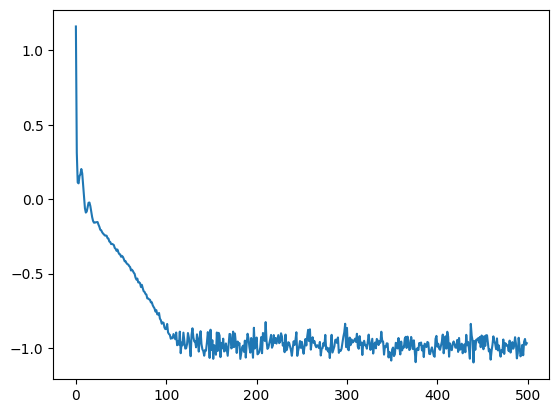

In [92]:
plt.plot(loss)

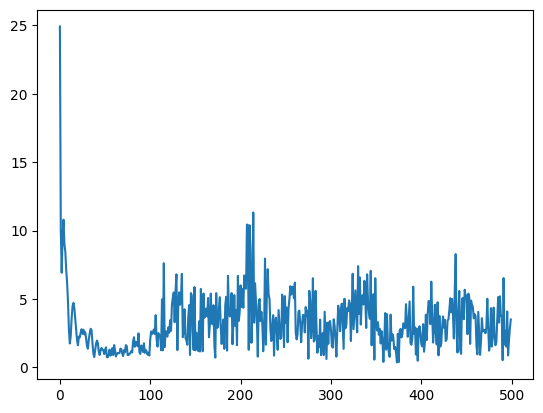

In [93]:
plt.plot(grad_norm)

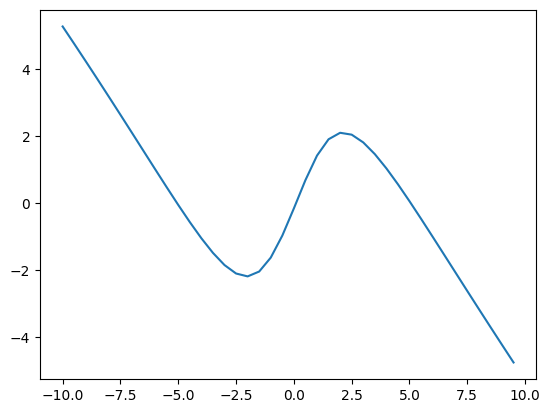

In [94]:
g, s = score.score_approx(-10, 10, 0.5)
g, s = g.numpy().T, s.numpy().T
plt.plot(g[0], s[0])

In [95]:
init_samples = standard_gaussian_1d().sample((1000, ))
samples = score.sample_langevin(
	init_samples = init_samples,
	n_steps = 1000,
	epsilon = 0.1
)

100%|██████████| 1000/1000 [00:00<00:00, 2045.70it/s]


(array([ 53., 289., 184.,  26.,   1.,   0.,  12., 126., 238.,  71.]),
 array([-7.77703094, -6.24192858, -4.70682621, -3.17172384, -1.63662148,
        -0.10151911,  1.43358326,  2.96868563,  4.50378799,  6.03889036,
         7.57399273]),
 <BarContainer object of 10 artists>)

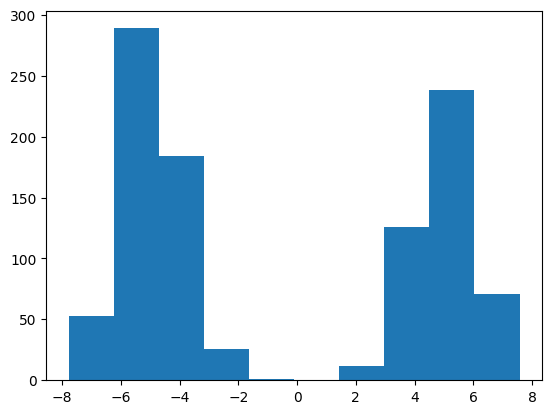

In [96]:
init_samples = init_samples.numpy().T
samples = samples.numpy().T
plt.hist(samples[0])